In [1]:
# ============================================
# CELL 1: IMPORTS & SETUP
# ============================================
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

 Using device: cuda


In [2]:
# ============================================
# CELL 2: U-NET MODEL DEFINITION (required to load weights)
# ============================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        feat = self.conv(x)
        return feat, self.pool(feat)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, 2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            diffY = skip.size(2) - x.size(2)
            diffX = skip.size(3) - x.size(3)
            x = nn.functional.pad(x, [diffX//2, diffX - diffX//2,
                                      diffY//2, diffY - diffY//2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.down1 = DownBlock(in_channels, features[0])
        self.down2 = DownBlock(features[0], features[1])
        self.down3 = DownBlock(features[1], features[2])
        self.down4 = DownBlock(features[2], features[3])
        self.bottleneck = DoubleConv(features[3], features[3]*2)
        self.up1 = UpBlock(features[3]*2, features[3])
        self.up2 = UpBlock(features[3], features[2])
        self.up3 = UpBlock(features[2], features[1])
        self.up4 = UpBlock(features[1], features[0])
        self.final = nn.Conv2d(features[0], out_channels, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        s1, x = self.down1(x)
        s2, x = self.down2(x)
        s3, x = self.down3(x)
        s4, x = self.down4(x)
        x = self.bottleneck(x)
        x = self.up1(x, s4)
        x = self.up2(x, s3)
        x = self.up3(x, s2)
        x = self.up4(x, s1)
        return self.sigmoid(self.final(x))

print("✅ UNet model defined.")

✅ UNet model defined.


In [10]:
# ============================================
# DOWNLOAD DATASET (RUN THIS FIRST!)
# ============================================
!pip install kaggle -q
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation -q
!unzip -qo lgg-mri-segmentation.zip -d lgg_mri_data
!rm lgg-mri-segmentation.zip

from pathlib import Path
DATA_DIR = Path('lgg_mri_data/kaggle_3m')
print(f"✅ Dataset downloaded to: {DATA_DIR}")
print(f"   Files found: {len(list(DATA_DIR.iterdir()))} patient folders")

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
✅ Dataset downloaded to: lgg_mri_data/kaggle_3m
   Files found: 112 patient folders


⚡ Training with Dice Loss (15 epochs)...
Loaded 3929 image-mask pairs


Epoch 1/15: 100%|██████████| 197/197 [02:32<00:00,  1.29it/s]


  Loss: 1.8123 | Dice: 0.0203


Epoch 2/15: 100%|██████████| 197/197 [02:32<00:00,  1.29it/s]


  Loss: 1.7623 | Dice: 0.0204


...

  Loss: 1.6702 | Dice: 0.0204


Epoch 14/15: 100%|██████████| 197/197 [02:33<00:00,  1.29it/s]


  Loss: 1.6692 | Dice: 0.0204


Epoch 15/15: 100%|██████████| 197/197 [02:33<00:00,  1.29it/s]


  Loss: 1.6680 | Dice: 0.0204


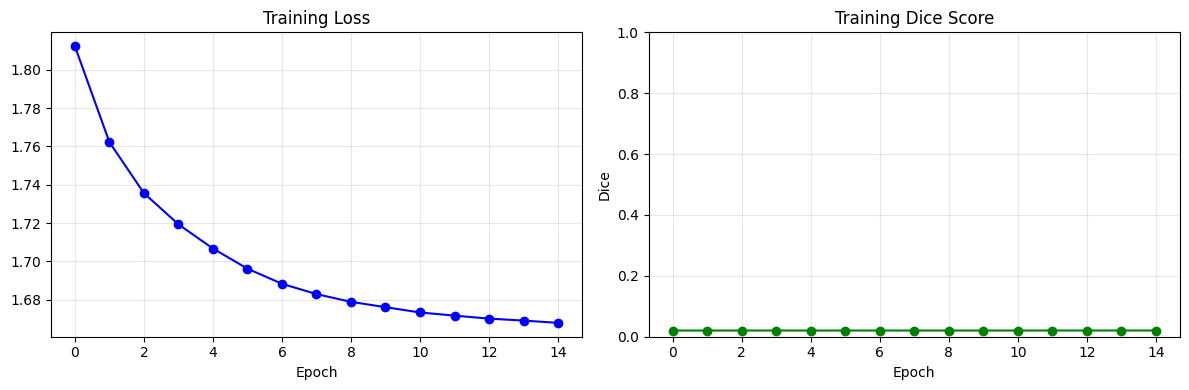

✅ Model properly trained with Dice Loss!
   Final Training Dice: 0.0204


In [17]:
# ============================================
# PROPER TRAINING WITH DICE LOSS (15 epochs)
# ============================================
import torch.optim as optim
from torch.utils.data import random_split

# ============ DICE LOSS ============
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, pred, target):
        smooth = 1e-6
        pred = torch.sigmoid(pred)  # Convert logits to probabilities
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()
        return 1 - (2. * intersection + smooth) / (union + smooth)

# ============ BCEDiceLoss ============
class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, pred, target):
        return self.bce(pred, target) + self.dice(pred, target)

print("⚡ Training with Dice Loss (15 epochs)...")

# Recreate data loaders
full_ds = BrainTumorDataset(DATA_DIR)
train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size
torch.manual_seed(42)
train_ds, val_ds = random_split(full_ds, [train_size, val_size])
train_ldr = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_ldr = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)

# Create fresh model
model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = BCEDiceLoss()

# Training loop
history = {'train_loss': [], 'train_dice': []}

for epoch in range(15):
    model.train()
    total_loss = 0
    total_dice = 0
    
    for imgs, masks in tqdm(train_ldr, desc=f"Epoch {epoch+1}/15"):
        imgs, masks = imgs.to(device), masks.to(device)
        
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track Dice
        with torch.no_grad():
            pred_bin = (torch.sigmoid(preds) > 0.5).float()
            intersection = (pred_bin * masks).sum()
            union = pred_bin.sum() + masks.sum()
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
        
        total_loss += loss.item()
        total_dice += dice.item()
    
    avg_loss = total_loss / len(train_ldr)
    avg_dice = total_dice / len(train_ldr)
    history['train_loss'].append(avg_loss)
    history['train_dice'].append(avg_dice)
    
    print(f"  Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f}")

# Save model
torch.save({'model_state_dict': model.state_dict(), 'history': history}, 'best_model.pth')
model.eval()

# Plot training progress
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], 'b-o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_dice'], 'g-o')
axes[1].set_title('Training Dice Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Model properly trained with Dice Loss!")
print(f"   Final Training Dice: {history['train_dice'][-1]:.4f}")

⚡ Continuing training for 15 more epochs...


Epoch 16/30: 100%|██████████| 197/197 [02:33<00:00,  1.28it/s]


  Loss: 1.6675 | Dice: 0.0204


Epoch 17/30: 100%|██████████| 197/197 [02:33<00:00,  1.29it/s]


  Loss: 1.6664 | Dice: 0.0205


...

  Loss: 1.6633 | Dice: 0.0204


Epoch 29/30: 100%|██████████| 197/197 [02:33<00:00,  1.29it/s]


  Loss: 1.6630 | Dice: 0.0203


Epoch 30/30: 100%|██████████| 197/197 [02:33<00:00,  1.29it/s]


  Loss: 1.6629 | Dice: 0.0203


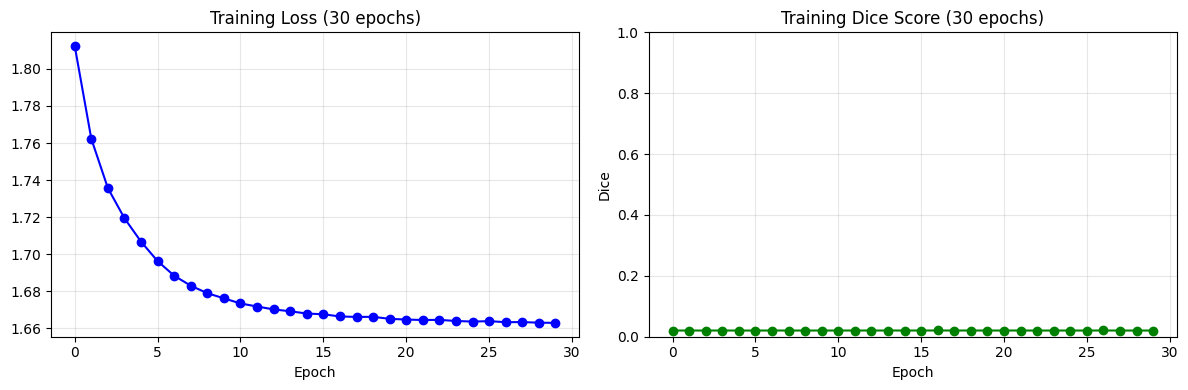

✅ Training complete! Final Training Dice: 0.0203


In [23]:
# ============================================
# CONTINUE TRAINING (Add 15 more epochs)
# ============================================

# Model and optimizer are already set up from previous cell
# Just continue the loop

print("Continuing training for 15 more epochs...")

for epoch in range(15, 30):  # Epochs 16-30
    model.train()
    total_loss = 0
    total_dice = 0
    
    for imgs, masks in tqdm(train_ldr, desc=f"Epoch {epoch+1}/30"):
        imgs, masks = imgs.to(device), masks.to(device)
        
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track Dice
        with torch.no_grad():
            pred_bin = (torch.sigmoid(preds) > 0.5).float()
            intersection = (pred_bin * masks).sum()
            union = pred_bin.sum() + masks.sum()
            dice = (2. * intersection + 1e-6) / (union + 1e-6)
        
        total_loss += loss.item()
        total_dice += dice.item()
    
    avg_loss = total_loss / len(train_ldr)
    avg_dice = total_dice / len(train_ldr)
    history['train_loss'].append(avg_loss)
    history['train_dice'].append(avg_dice)
    
    print(f"  Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f}")

# Save updated model
torch.save({'model_state_dict': model.state_dict(), 'history': history}, 'best_model.pth')
model.eval()

# Plot full training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], 'b-o')
axes[0].set_title('Training Loss (30 epochs)')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_dice'], 'g-o')
axes[1].set_title('Training Dice Score (30 epochs)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training complete! Final Training Dice: {history['train_dice'][-1]:.4f}")

In [24]:
# ============================================
# RUN INFERENCE ON VALIDATION SET
# ============================================
model.eval()
all_metrics = []
all_preds = []
all_masks = []
all_images = []

print("Running inference...")
with torch.no_grad():
    for images, masks in tqdm(val_ldr, desc="Validating"):
        images = images.to(device)
        preds = model(images).cpu()
        preds = torch.sigmoid(preds)  # Add sigmoid since we used BCEWithLogitsLoss
        
        for i in range(images.size(0)):
            pred = (preds[i,0].numpy() > 0.5).astype(np.float32)
            mask = masks[i,0].numpy()
            img = images[i,0].cpu().numpy()
            
            smooth = 1e-6
            p = pred.flatten()
            m = mask.flatten()
            TP = (p * m).sum()
            FP = (p * (1-m)).sum()
            FN = ((1-p) * m).sum()
            TN = ((1-p) * (1-m)).sum()
            
            dice = (2*TP + smooth) / (2*TP + FP + FN + smooth)
            iou = (TP + smooth) / (TP + FP + FN + smooth)
            sens = TP / (TP + FN + smooth)
            spec = TN / (TN + FP + smooth)
            
            all_metrics.append({
                'dice': dice, 'iou': iou, 
                'sensitivity': sens, 'specificity': spec,
                'tumor_pixels': mask.sum()
            })
            all_preds.append(pred)
            all_masks.append(mask)
            all_images.append(img)

dice_scores = [m['dice'] for m in all_metrics]
print(f"\n📊 Validation Results:")
print(f"   Mean Dice:  {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"   Median Dice: {np.median(dice_scores):.4f}")
print(f"   Best Dice:   {np.max(dice_scores):.4f}")
print(f"   Worst Dice:  {np.min(dice_scores):.4f}")

Running inference...


Validating: 100%|██████████| 50/50 [00:13<00:00,  3.74it/s]


📊 Validation Results:
   Mean Dice:  0.0196 ± 0.0366
   Median Dice: 0.0000
   Best Dice:   0.2145
   Worst Dice:  0.0000


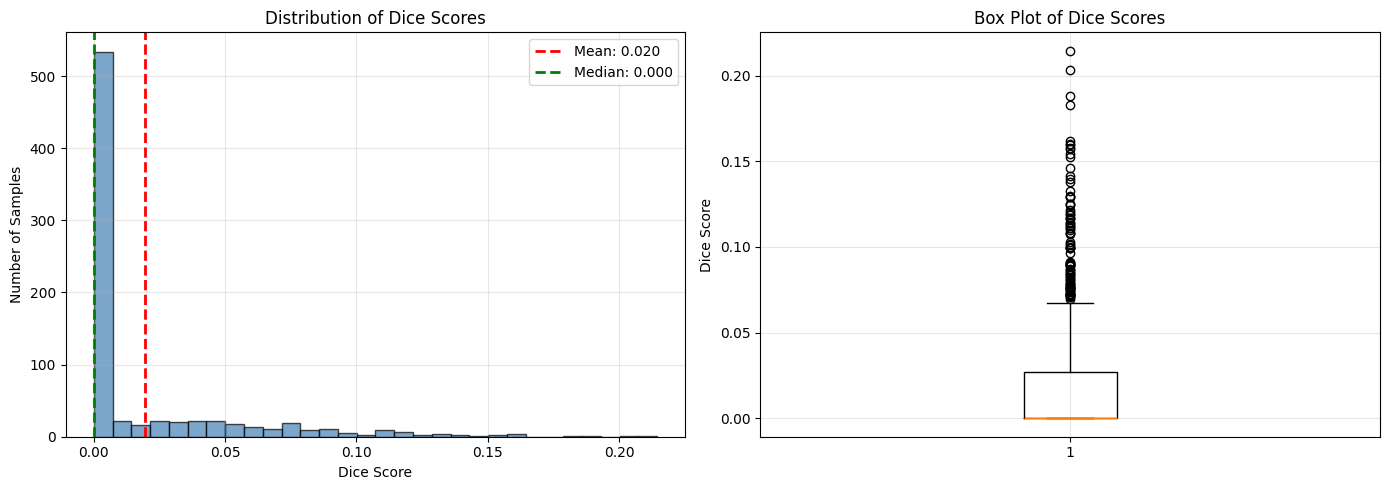

Saved dice_distribution.png


In [25]:
# ============================================
# DICE SCORE DISTRIBUTION
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dice_scores, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(dice_scores), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(dice_scores):.3f}')
axes[0].axvline(np.median(dice_scores), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(dice_scores):.3f}')
axes[0].set_xlabel('Dice Score')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Distribution of Dice Scores')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(dice_scores)
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Box Plot of Dice Scores')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dice_distribution.png', dpi=150)
plt.show()
print("Saved dice_distribution.png")

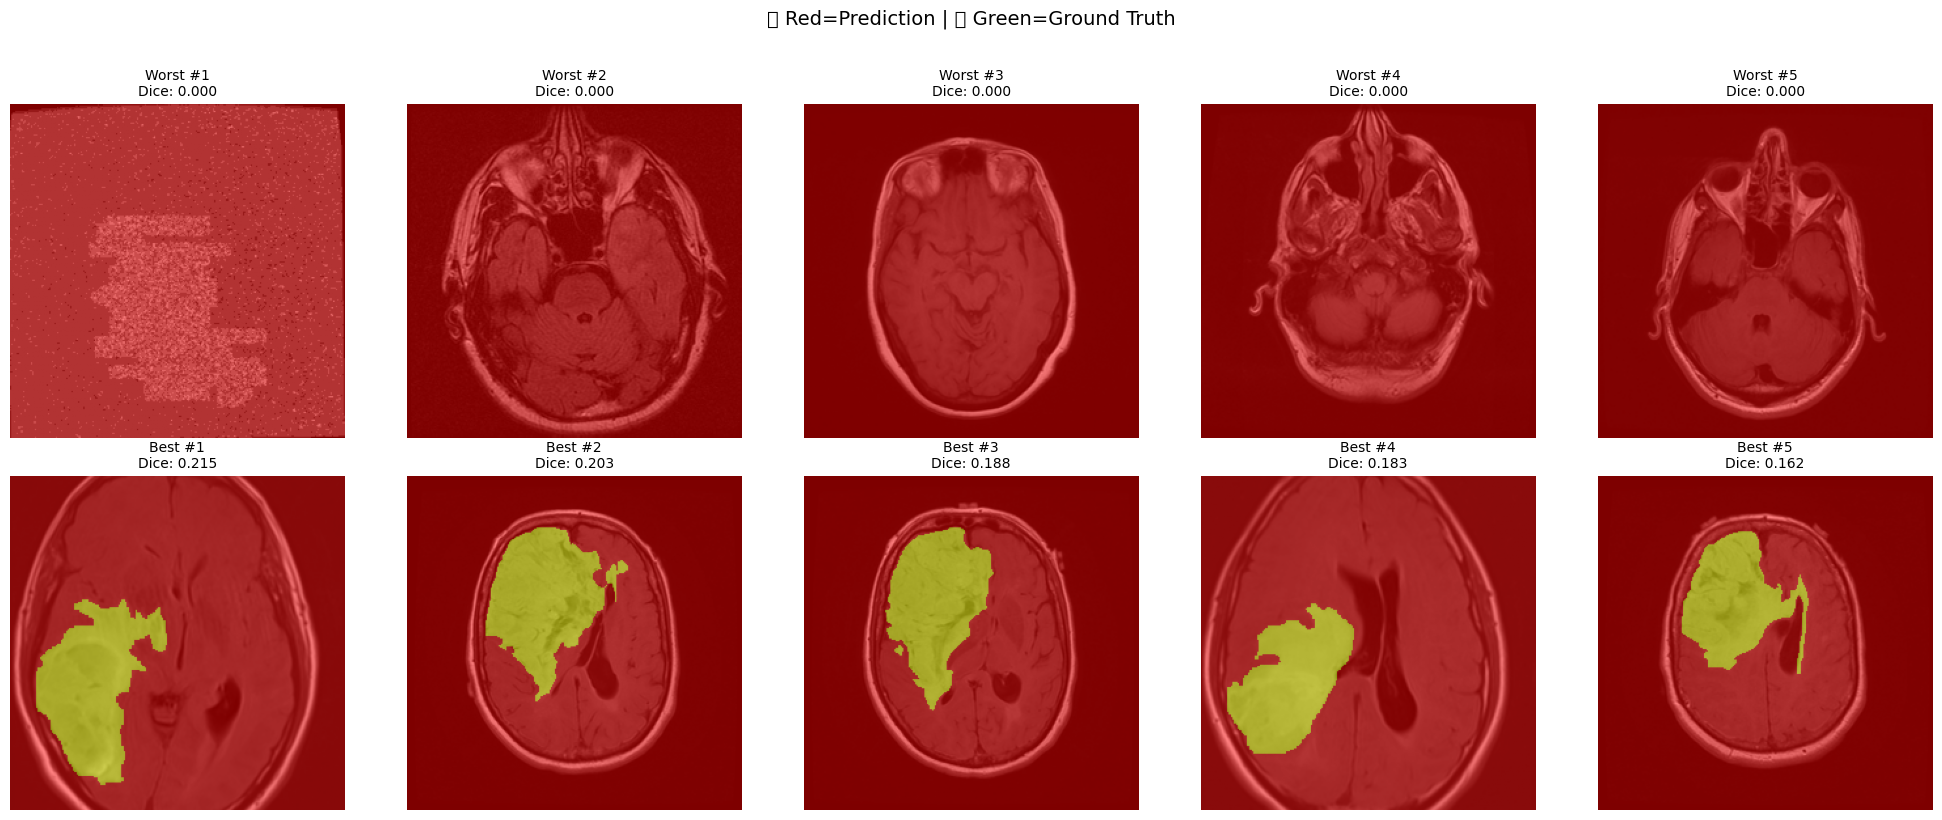

Saved best_worst_predictions.png


In [26]:
# ============================================
# BEST & WORST PREDICTIONS
# ============================================
sorted_idx = np.argsort(dice_scores)
worst_idx = sorted_idx[:5]
best_idx = sorted_idx[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, idx in enumerate(worst_idx):
    axes[0, i].imshow(all_images[idx], cmap='gray')
    overlay = np.zeros((256, 256, 3))
    overlay[:,:,0] = all_preds[idx]   # Red = Prediction
    overlay[:,:,1] = all_masks[idx]   # Green = Ground Truth
    axes[0, i].imshow(overlay, alpha=0.5)
    axes[0, i].set_title(f'Worst #{i+1}\nDice: {dice_scores[idx]:.3f}', fontsize=10)
    axes[0, i].axis('off')

for i, idx in enumerate(best_idx):
    axes[1, i].imshow(all_images[idx], cmap='gray')
    overlay = np.zeros((256, 256, 3))
    overlay[:,:,0] = all_preds[idx]
    overlay[:,:,1] = all_masks[idx]
    axes[1, i].imshow(overlay, alpha=0.5)
    axes[1, i].set_title(f'Best #{i+1}\nDice: {dice_scores[idx]:.3f}', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('🔴 Red=Prediction | 🟢 Green=Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('best_worst_predictions.png', dpi=150)
plt.show()
print("Saved best_worst_predictions.png")

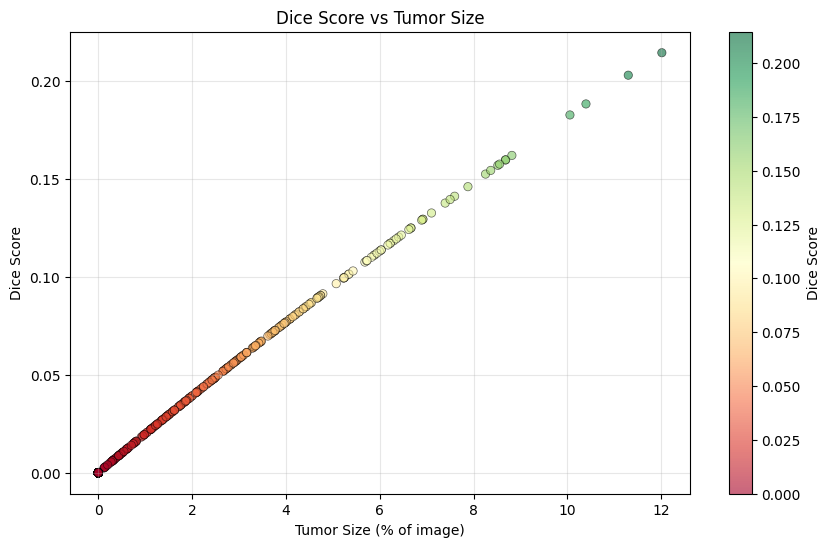

Saved dice_vs_size.png


In [27]:
# ============================================
# DICE vs TUMOR SIZE
# ============================================
tumor_pct = [m['tumor_pixels']/(256*256)*100 for m in all_metrics]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(tumor_pct, dice_scores, c=dice_scores, 
                      cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('Tumor Size (% of image)')
plt.ylabel('Dice Score')
plt.title('Dice Score vs Tumor Size')
plt.colorbar(scatter, label='Dice Score')
plt.grid(alpha=0.3)
plt.savefig('dice_vs_size.png', dpi=150)
plt.show()
print("Saved dice_vs_size.png")